In [1]:
import pandas as pd
from collections import defaultdict
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from scipy.stats import ttest_ind
from itertools import combinations
from utils import *

In [2]:
raw_counts_sarcopenia = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/public_datasets/sarcopenia_bulk_RNA/GSE226151_SKELETAL_MUSCLE_READ_COUNT.txt'
series_matrix_sarcopenia = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/public_datasets/sarcopenia_bulk_RNA/GSE226151_series_matrix.txt'
# read txt into a df
sarcopenia_counts = pd.read_csv(raw_counts_sarcopenia, sep='\t')

In [3]:
lines = read_series_matrix(series_matrix_sarcopenia)
metadata_dict = parse_sample_metadata(lines)
mapping_df = clean_metadata_df(metadata_dict)
# expression_df = pd.read_csv("expression_matrix.tsv")  # Load separately
female_expr_df, male_expr_df = split_expression_by_sex(sarcopenia_counts, mapping_df)

In [4]:
mapping_df.head()

,sample_id,sex,disease_state,label
0,"""Skeletal muscle, HA 01""",Female,healthy aged,HA_1
1,"""Skeletal muscle, HA 02""",Female,healthy aged,HA_2
2,"""Skeletal muscle, HA 03""",Female,healthy aged,HA_3
3,"""Skeletal muscle, HA 04""",Female,healthy aged,HA_4
4,"""Skeletal muscle, HA 05""",Female,healthy aged,HA_5


In [7]:
dna_repair_gene_sets_folder = "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_repair"
# read all gmt files in the folder
gene_sets = {}
for file in os.listdir(dna_repair_gene_sets_folder):
    if file.endswith(".gmt"):
        file_gene_sets = load_gmt(os.path.join(dna_repair_gene_sets_folder, file))
        # Flatten the structure - add pathway names directly as keys
        gene_sets.update(file_gene_sets)

{'KEGG_NUCLEOTIDE_EXCISION_REPAIR': ['CCNH',
  'CDK7',
  'CETN2',
  'CUL4A',
  'CUL4B',
  'DDB1',
  'DDB2',
  'ERCC1',
  'ERCC2',
  'ERCC3',
  'ERCC4',
  'ERCC5',
  'ERCC6',
  'ERCC8',
  'GTF2H1',
  'GTF2H2',
  'GTF2H3',
  'GTF2H4',
  'GTF2H5',
  'LIG1',
  'MNAT1',
  'PCNA',
  'POLD1',
  'POLD2',
  'POLD3',
  'POLD4',
  'POLE',
  'POLE2',
  'POLE3',
  'POLE4',
  'RAD23A',
  'RAD23B',
  'RBX1',
  'RFC1',
  'RFC2',
  'RFC3',
  'RFC4',
  'RFC5',
  'RPA1',
  'RPA2',
  'RPA3',
  'RPA4',
  'XPA',
  'XPC'],
 'KEGG_HOMOLOGOUS_RECOMBINATION': ['BLM',
  'BRCA2',
  'EME1',
  'MRE11',
  'MUS81',
  'NBN',
  'POLD1',
  'POLD2',
  'POLD3',
  'POLD4',
  'RAD50',
  'RAD51',
  'RAD51B',
  'RAD51C',
  'RAD51D',
  'RAD52',
  'RAD54B',
  'RAD54L',
  'RPA1',
  'RPA2',
  'RPA3',
  'RPA4',
  'SEM1',
  'SSBP1',
  'TOP3A',
  'TOP3B',
  'XRCC2',
  'XRCC3'],
 'HALLMARK_DNA_REPAIR': ['AAAS',
  'ADA',
  'ADCY6',
  'ADRM1',
  'AGO4',
  'AK1',
  'AK3',
  'ALYREF',
  'APRT',
  'ARL6IP1',
  'BCAM',
  'BCAP31',
  'BOLA2

In [31]:
# Select one pathway to score
pathway_name = "REACTOME_HOMOLOGOUS_RECOMBINATION_REPAIR_OF_REPLICATION_INDEPENDENT_DOUBLE_STRAND_BREAKS"
genes_for_pathway = gene_sets[pathway_name]  # this is a list
score_df = calculate_geneset_score(female_expr_df, up_genes=genes_for_pathway, mapping_df=mapping_df)

Using 16 upregulated genes


In [15]:
palette_male = {
    "healthy aged": "#87CEEB",      # light sky blue
    "pre-sarcopenia": "#4682B4",    # steel blue  
    "sarcopenia": "#191970"         # midnight blue
}
palette_female = {
    "healthy aged": "#FFB6C1",      # light pink
    "pre-sarcopenia": "#DC143C",    # crimson
    "sarcopenia": "#8B0000"         # dark red
}

/ocean/projects/cis240075p/asachan/bio_informatics_analysis/bulk_rna_analysis/skm_sarcopenia_human/utils.py:273: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/ocean/projects/cis240075p/asachan/bio_informatics_analysis/bulk_rna_analysis/skm_sarcopenia_human/utils.py:279: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/ocean/projects/cis240075p/asachan/bio_informatics_analysis/bulk_rna_analysis/skm_sarcopenia_human/utils.py:285: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


<Figure size 640x480 with 0 Axes>

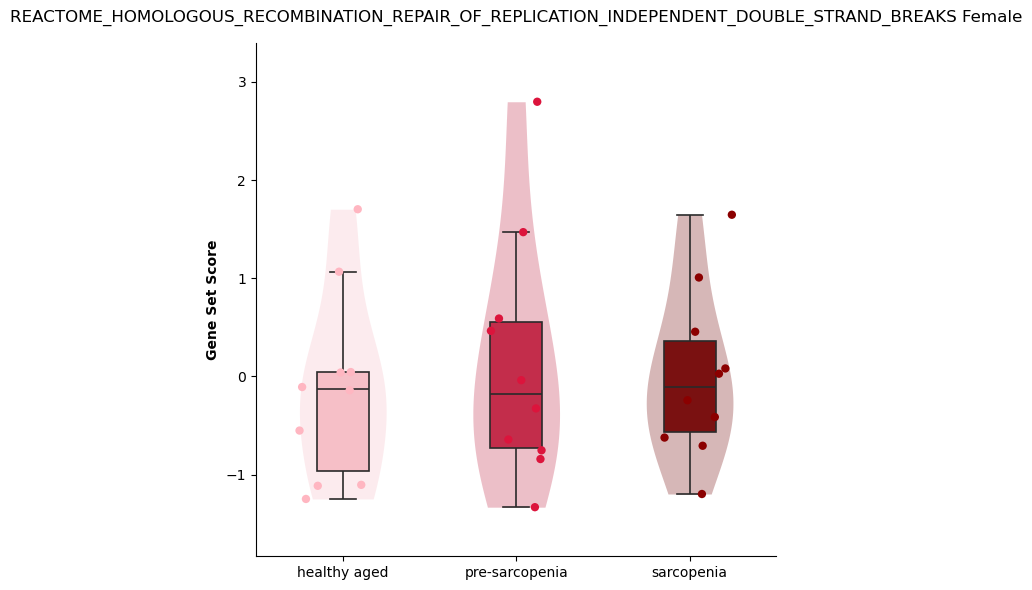

In [32]:
plot_geneset_score_violin_box(
    score_df,
    category_col="disease_state",
    title= pathway_name + " Female",
    palette=palette_female
)

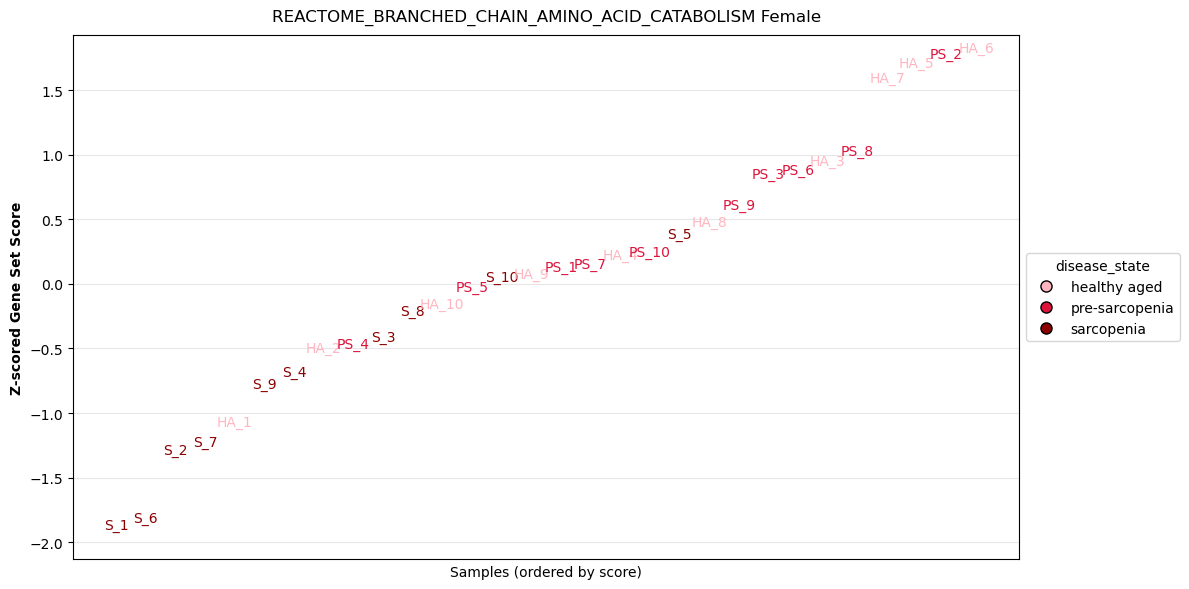

In [18]:
plot_geneset_scores_scatter(
    score_df, 
    category_col="disease_state", 
    title= pathway_name + " Female",
    ylabel="Z-scored Gene Set Score",
    palette=palette_female
)
